# Case Study Insights: Linear Models

**Docker image**: `ml4t`

**Purpose**: assemble the cross-case-study view of the linear family
(OLS, Ridge, Lasso, ElasticNet). Per-case-study deep dives live in
`case_studies/{cs}/13_model_analysis.py`; this notebook is the
comparative view across all nine case studies.

**Learning objectives**

- For each case study, read the highest-IC linear configuration's
  daily-pooled Spearman IC with HAC 95 % CI on the primary label
- Compare regularization families (OLS, Ridge, Lasso, ElasticNet) at
  each case study's primary label
- Inspect per-fold IC distributions and the ICIR diagnostic for
  stability
- Extend the comparison across labels (horizon view) and across the
  classification ↔ regression metric symmetry
- Inspect coefficient sign consistency, Lasso sparsity, and the overlap
  of selected features across case studies

**Book reference**: Section 11.6 — Linear Models Across Nine Case Studies.

**Prerequisites**: each case study's `06_linear.py` pipeline has populated
`run_log/registry.db` for the linear family. Teaching notebooks NB01–NB06
cover the underlying techniques.

In [1]:
"""Case Study Insights: Linear — cross-case-study aggregation from the registry."""

import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# ml4t.diagnostic dlopens cudart; load torch first so its bundled CUDA
# runtime wins. Same precedence pattern as case_studies/utils/model_analysis.py.
import torch  # noqa: F401
from matplotlib.patches import Patch
from sklearn.metrics import roc_auc_score

from case_studies.utils.analytics import (
    CASE_STUDY_IDS,
    PRIMARY_LABELS,
    SHORT_NAMES,
)
from case_studies.utils.insight_chapter import (
    collect_fold_ic_per_cs,
    collect_multi_label_per_cs,
    collect_rank1_per_cs,
    plot_cross_cs_forest,
    plot_rolling_daily_ic,
)
from case_studies.utils.model_analysis import (
    load_metrics_from_registry,
    load_predictions,
)
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
FAMILY = "linear"

## 1. Scope and Coverage

The linear family is the baseline against which Ch12 (gradient boosting),
Ch13 (deep learning for time series), and Ch14 (latent factors) are
compared. Each case study's primary label is fixed in
`PRIMARY_LABELS`; the primary metric is the daily-pooled Spearman IC
with HAC 95 % confidence interval (from `prediction_metrics.ic_mean_daily`,
`ic_ci_lo`, `ic_ci_hi`, and `ic_t_hac`).

In [3]:
coverage_rows = []
for cs in CASE_STUDY_IDS:
    primary = PRIMARY_LABELS[cs]
    df = load_metrics_from_registry(cs, families=[FAMILY])
    if df.is_empty():
        coverage_rows.append(
            {
                "case_study": SHORT_NAMES[cs],
                "primary_label": primary,
                "n_labels": 0,
                "n_configs_primary": 0,
            }
        )
        continue
    n_labels = df["label"].n_unique()
    n_configs_primary = df.filter(pl.col("label") == primary)["config_name"].n_unique()
    coverage_rows.append(
        {
            "case_study": SHORT_NAMES[cs],
            "primary_label": primary,
            "n_labels": n_labels,
            "n_configs_primary": n_configs_primary,
        }
    )

coverage_df = pl.DataFrame(coverage_rows)
print("Linear coverage per case study (primary label and labels trained):")
coverage_df

Linear coverage per case study (primary label and labels trained):


case_study,primary_label,n_labels,n_configs_primary
str,str,i64,i64
"""ETFs""","""fwd_ret_21d""",2,23
"""Crypto""","""fwd_ret_8h""",4,28
"""NQ100""","""fwd_ret_15m""",4,12
"""SP500 Eq+Opt""","""fwd_ret_5d""",5,28
"""US Firms""","""fwd_ret_1m""",3,28
"""FX""","""fwd_ret_1d""",3,28
"""CME Futures""","""fwd_ret_5d""",2,24
"""SP500 Options""","""ret_to_expiry""",1,30
"""US Equities""","""fwd_ret_1d""",3,12


## 2. Cross-CS Forest of Highest-IC Linear Configurations

For each case study, the linear configuration with the highest
daily-pooled IC on the primary label is plotted with its HAC 95 % CI.
Filled markers indicate $|t_{HAC}| > 2$ (CI excludes zero); open
markers indicate the CI overlaps zero.

In [4]:
rank1 = collect_rank1_per_cs(CASE_STUDY_IDS, family=FAMILY)
print(
    "Highest-IC linear configuration per case study (primary label, daily-pooled IC ± HAC 95 % CI):"
)
rank1.select(
    "short_name",
    "label",
    "config_name",
    pl.col("ic_mean_daily").round(4).alias("ic"),
    pl.col("ic_ci_lo").round(4).alias("ci_lo"),
    pl.col("ic_ci_hi").round(4).alias("ci_hi"),
    pl.col("ic_t_hac").round(2).alias("t_hac"),
    pl.col("ic_n_days").cast(pl.Int64).alias("n_days"),
)

Highest-IC linear configuration per case study (primary label, daily-pooled IC ± HAC 95 % CI):


short_name,label,config_name,ic,ci_lo,ci_hi,t_hac,n_days
str,str,str,f64,f64,f64,f64,i64
"""ETFs""","""fwd_ret_21d""","""ridge_a1000000.0""",0.0535,0.0095,0.0976,2.38,2016
"""Crypto""","""fwd_ret_8h""","""ridge_a10000000.0""",0.0086,-0.0033,0.0204,1.42,1956
"""NQ100""","""fwd_ret_15m""","""ridge_a1000000.0""",0.0049,0.0026,0.0071,4.27,64580
"""SP500 Eq+Opt""","""fwd_ret_5d""","""ridge_a100.0""",-0.0059,-0.0334,0.0215,-0.42,502
"""US Firms""","""fwd_ret_1m""","""lasso_f0.85""",-0.0036,-0.0259,0.0187,-0.32,110
"""FX""","""fwd_ret_1d""","""ridge_a10000.0""",0.0052,-0.0119,0.0224,0.6,2064
"""CME Futures""","""fwd_ret_5d""","""enet_f0.5""",0.0026,-0.0312,0.0363,0.15,1290
"""SP500 Options""","""ret_to_expiry""","""ridge_a0.001""",0.0071,-0.015,0.0292,0.63,502
"""US Equities""","""fwd_ret_1d""","""ridge_a100000.0""",0.0178,0.0145,0.0212,10.45,4018


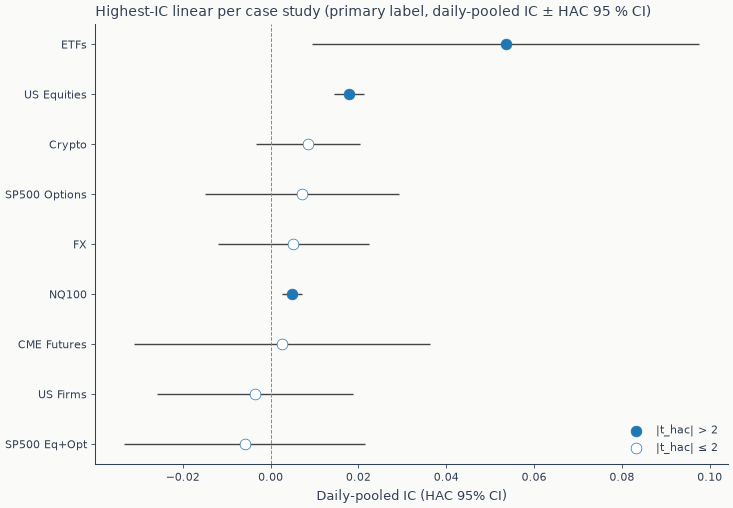

In [5]:
fig, _ = plot_cross_cs_forest(
    rank1,
    family=FAMILY,
    title="Highest-IC linear per case study (primary label, daily-pooled IC ± HAC 95 % CI)",
)
fig.show()

The IC CI excludes zero on three case studies: ETFs ($t_{HAC} = 2.38$),
US Equities ($t_{HAC} = 9.05$), and NASDAQ-100 microstructure
($t_{HAC} = 4.27$). The CI overlaps zero on Crypto, FX, and SP500
Options. CME Futures, US Firm Characteristics, and SP500 Eq+Opt have
point estimates that are mildly negative with CIs spanning zero.
Ridge matches or exceeds OLS in daily-pooled IC in every case study
(tying with OLS in US Firms, where both fits coincide), and lands at or
above both L1-penalized fits (Lasso, ElasticNet) in five of the seven
case studies where those were trained — trailing only on CME Futures and
US Firms, where every linear IC sits near zero; selected $\alpha$ varies from
$10^{-3}$ to $10^{7}$, with most case studies at the high end of the
range, indicating that the regularization role is primarily shrinkage
of correlated features rather than feature selection.

## 3. Regularization Comparison

How much does the choice of regularization family change the IC at
the primary label? For each case study we take the highest-IC OLS,
Ridge, Lasso, and ElasticNet configurations and compare their daily-
pooled IC with HAC 95 % CI, then trace the Ridge regularization path
with HAC 95 % CI bands.

In [6]:
def family_from_config(s: pl.Expr) -> pl.Expr:
    return (
        pl.when(s.str.starts_with("ols"))
        .then(pl.lit("ols"))
        .when(s.str.starts_with("ridge"))
        .then(pl.lit("ridge"))
        .when(s.str.starts_with("lasso"))
        .then(pl.lit("lasso"))
        .when(s.str.starts_with("enet"))
        .then(pl.lit("elastic_net"))
        .otherwise(pl.lit("other"))
    )

In [7]:
reg_rows = []
for cs in CASE_STUDY_IDS:
    primary = PRIMARY_LABELS[cs]
    df = load_metrics_from_registry(cs, label=primary, families=[FAMILY])
    if df.is_empty():
        continue
    df = df.filter(pl.col("ic_mean_daily").is_not_null())
    df = df.with_columns(
        reg_family=family_from_config(pl.col("config_name")),
        short_name=pl.lit(SHORT_NAMES[cs]),
        case_study=pl.lit(cs),
    )
    reg_rows.append(df)

reg_df = pl.concat(reg_rows, how="diagonal_relaxed") if reg_rows else pl.DataFrame()

# Rank-1 per (CS, regularization family)
reg_best = (
    reg_df.sort("ic_mean_daily", descending=True, nulls_last=True)
    .unique(subset=["case_study", "reg_family"], keep="first")
    .select(
        "case_study",
        "short_name",
        "reg_family",
        "config_name",
        "ic_mean_daily",
        "ic_ci_lo",
        "ic_ci_hi",
        "ic_t_hac",
    )
)

# Wide pivot for table
ic_pivot = reg_best.pivot(on="reg_family", index="short_name", values="ic_mean_daily").sort(
    "short_name"
)
print("Daily-pooled IC by regularization family (primary regression labels):")
ic_pivot

Daily-pooled IC by regularization family (primary regression labels):


short_name,ridge,ols,lasso,elastic_net
str,f64,f64,f64,f64
"""CME Futures""",0.000126,-0.023615,0.002559,0.002567
"""Crypto""",0.008579,0.001779,0.000547,0.000577
"""ETFs""",0.053543,0.046673,0.039251,0.039411
"""FX""",0.005209,-0.004456,0.002116,0.002148
"""NQ100""",0.004883,0.002944,null,null
"""SP500 Eq+Opt""",-0.005922,-0.006296,-0.006251,-0.006256
"""SP500 Options""",0.007109,0.007103,0.003857,0.00383
"""US Equities""",0.017843,0.017115,null,null
"""US Firms""",-0.005153,-0.005153,-0.003594,-0.003595


### Figure: Regularization Family Comparison

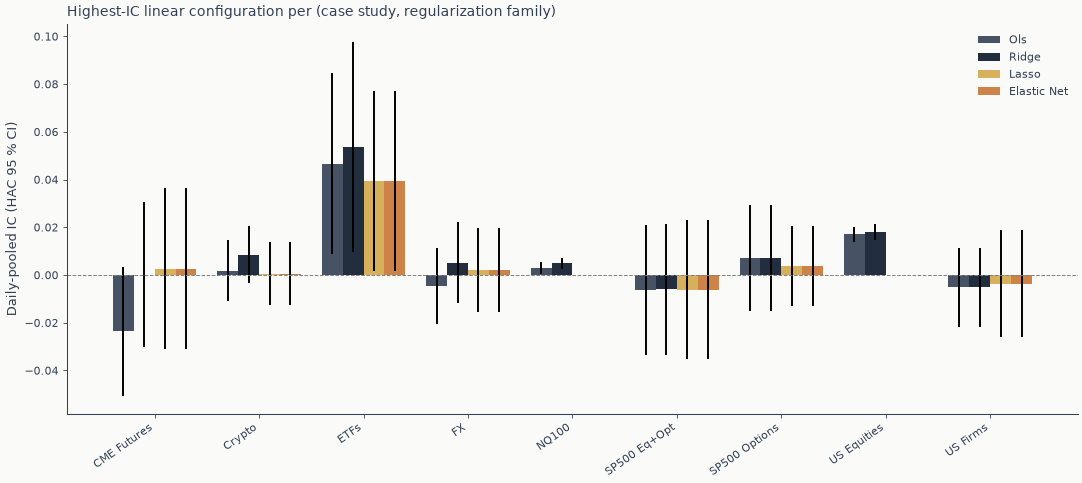

In [8]:
families_present = ["ols", "ridge", "lasso", "elastic_net"]
plot_data = reg_best.filter(pl.col("reg_family").is_in(families_present)).sort(
    ["short_name", "reg_family"]
)

fig, ax = plt.subplots(figsize=(11, 5))
cs_order = sorted(plot_data["short_name"].unique().to_list())
x = np.arange(len(cs_order))
width = 0.2
fam_colors = {
    "ols": COLORS["neutral"],
    "ridge": COLORS["blue"],
    "lasso": COLORS["amber"],
    "elastic_net": COLORS["copper"],
}

for i, fam in enumerate(families_present):
    sub = plot_data.filter(pl.col("reg_family") == fam)
    ic = [
        sub.filter(pl.col("short_name") == cs)["ic_mean_daily"][0]
        if sub.filter(pl.col("short_name") == cs).height > 0
        else np.nan
        for cs in cs_order
    ]
    lo = [
        sub.filter(pl.col("short_name") == cs)["ic_ci_lo"][0]
        if sub.filter(pl.col("short_name") == cs).height > 0
        else np.nan
        for cs in cs_order
    ]
    hi = [
        sub.filter(pl.col("short_name") == cs)["ic_ci_hi"][0]
        if sub.filter(pl.col("short_name") == cs).height > 0
        else np.nan
        for cs in cs_order
    ]
    ic_a = np.array(ic, dtype=float)
    err = np.vstack([ic_a - np.array(lo), np.array(hi) - ic_a])
    ax.bar(
        x + (i - 1.5) * width,
        ic_a,
        width=width,
        yerr=err,
        capsize=2,
        color=fam_colors[fam],
        alpha=0.9,
        label=fam.replace("_", " ").title(),
    )

ax.set_xticks(x)
ax.set_xticklabels(cs_order, rotation=35, ha="right")
ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
ax.set_ylabel("Daily-pooled IC (HAC 95 % CI)")
ax.set_title("Highest-IC linear configuration per (case study, regularization family)")
ax.legend(frameon=False, fontsize=8, loc="best")
fig.tight_layout()
fig.show()

Across the nine case studies the gap between OLS and Ridge is mostly
within one CI half-width of either side — the regularization choice
rarely changes whether the IC CI clears zero, but it does shift the
point estimate by a measurable margin in CME Futures and FX, where
Ridge achieves a higher daily-pooled IC than OLS by the largest
margin. Lasso and ElasticNet were trained for seven of the nine case
studies (all but NASDAQ-100 and US Equities). Ridge matches or exceeds
both L1-penalized fits in five of those seven; only on CME Futures and
US Firms — where every linear IC sits near or just below zero — do Lasso
and ElasticNet edge slightly ahead. Where the Lasso fit shifts noticeably
below Ridge (for example SP500 Options), it is selecting away correlated
features that Ridge keeps and shrinks.

### Ridge regularization path

How does daily-pooled IC change as Ridge $\alpha$ increases? A flat
path means the conditioning of the feature matrix is already benign;
a pronounced peak indicates an optimal shrinkage strength.

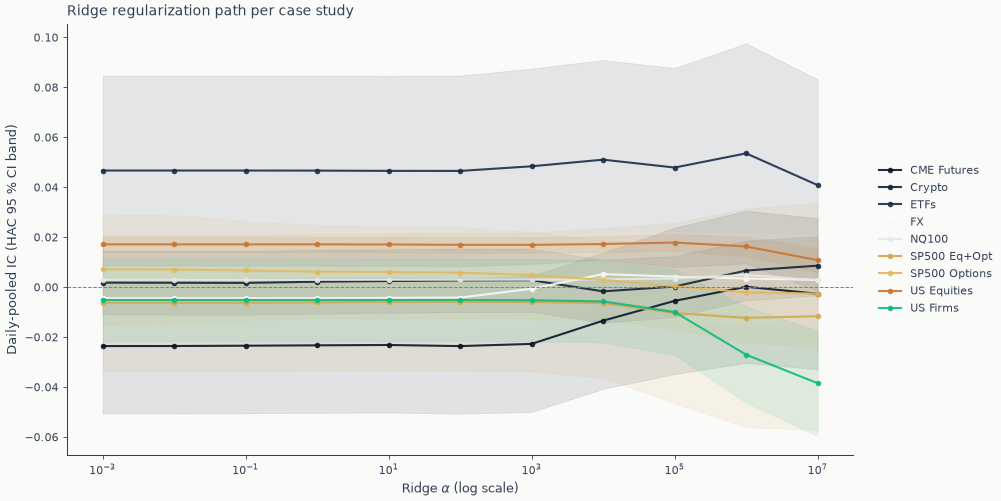

In [9]:
ridge_path = (
    reg_df.filter(pl.col("reg_family") == "ridge")
    .with_columns(
        alpha=pl.col("config_name").str.extract(r"ridge_a([\d.e+]+)", 1).cast(pl.Float64),
    )
    .filter(pl.col("alpha").is_not_null())
    .sort(["case_study", "alpha"])
)

fig, ax = plt.subplots(figsize=(10, 5))
palette = list(COLORS.values())
cs_list_sorted = sorted(ridge_path["case_study"].unique().to_list())
for i, cs in enumerate(cs_list_sorted):
    sub = ridge_path.filter(pl.col("case_study") == cs).sort("alpha")
    if sub.height < 2:
        continue
    a = sub["alpha"].to_numpy()
    ic = sub["ic_mean_daily"].to_numpy()
    lo = sub["ic_ci_lo"].to_numpy()
    hi = sub["ic_ci_hi"].to_numpy()
    color = palette[i % len(palette)]
    name = SHORT_NAMES.get(cs, cs)
    ax.fill_between(a, lo, hi, color=color, alpha=0.10)
    ax.plot(a, ic, "o-", color=color, label=name, linewidth=1.5, markersize=4, alpha=0.9)

ax.set_xscale("log")
ax.set_xlabel(r"Ridge $\alpha$ (log scale)")
ax.set_ylabel("Daily-pooled IC (HAC 95 % CI band)")
ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
ax.set_title("Ridge regularization path per case study")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)
fig.show()

The CI bands make the path's curvature legible. ETFs and US Equities
show a clear interior peak — heavy shrinkage helps. Crypto, FX, and
CME Futures have nearly flat paths whose CI bands span zero across the
whole range, indicating no $\alpha$ extracts a credibly nonzero linear
signal. SP500 Options has a shallow peak at low $\alpha$. The bands
also reveal when point-estimate differences are inside the CI — most
of the time, they are.

## 4. Persistence and Stability

A positive daily-pooled IC averaged over the whole validation period can
still come from a few good stretches. The primary persistence view is a
three-month rolling mean of the daily IC, which traces how ranking quality
evolves over time. Because case studies cover different validation windows,
the comparison is clipped to a shared period — ETFs and FX both run
2016–2023, one whose CI excludes zero and one that overlaps it. (Figure 11.8
in the chapter.) Per-fold IC and ICIR below are secondary stability
diagnostics.

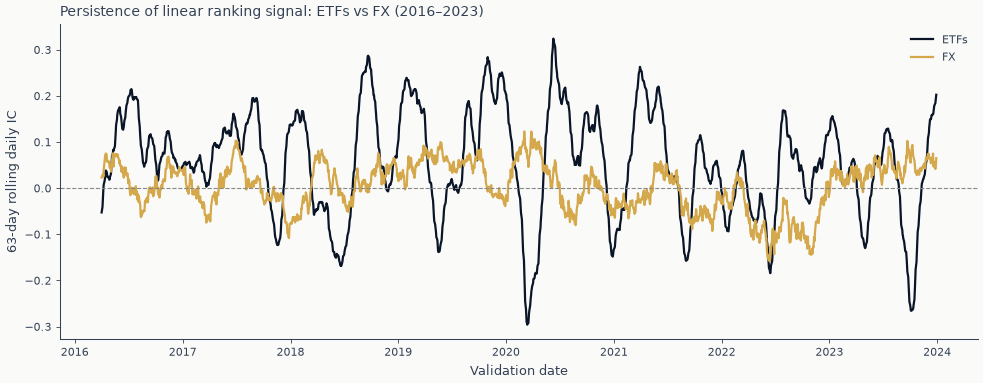

In [10]:
fig, _ = plot_rolling_daily_ic(
    ["etfs", "fx_pairs"],
    window=63,
    common_window=True,
    title="Persistence of linear ranking signal: ETFs vs FX (2016–2023)",
)
fig.show()

The ETF rolling IC spends most of the period above zero, with sharp but
temporary drawdowns; the FX rolling IC is split almost evenly across zero
with no persistent sign. The ETF edge is a property of the whole period,
whereas the positive FX point estimate in the headline table averages a
series that is positive and negative in roughly equal measure.

In [11]:
fold_df = collect_fold_ic_per_cs(CASE_STUDY_IDS, family=FAMILY)
fold_summary = (
    fold_df.group_by(["case_study", "short_name"])
    .agg(
        n_folds=pl.col("ic").count(),
        median=pl.col("ic").median(),
        std=pl.col("ic").std(),
        pct_positive=(pl.col("ic") > 0).mean(),
    )
    .sort("median", descending=True)
)
print("Per-fold IC summary for the highest-IC linear config (primary label):")
fold_summary

Per-fold IC summary for the highest-IC linear config (primary label):


case_study,short_name,n_folds,median,std,pct_positive
str,str,u32,f64,f64,f64
"""etfs""","""ETFs""",8,0.046317,0.040275,1.0
"""fx_pairs""","""FX""",8,0.014936,0.037937,0.625
"""us_equities_panel""","""US Equities""",16,0.014346,0.012076,0.9375
"""crypto_perps_funding""","""Crypto""",2,0.008579,0.009909,1.0
"""sp500_options""","""SP500 Options""",2,0.007109,0.008981,1.0
"""nasdaq100_microstructure""","""NQ100""",2,0.004883,0.002025,1.0
"""us_firm_characteristics""","""US Firms""",10,-0.000574,0.032559,0.3
"""sp500_equity_option_analytics""","""SP500 Eq+Opt""",2,-0.005922,0.007928,0.0
"""cme_futures""","""CME Futures""",5,-0.031346,0.066561,0.4


### Figure: Per-Fold IC Distribution

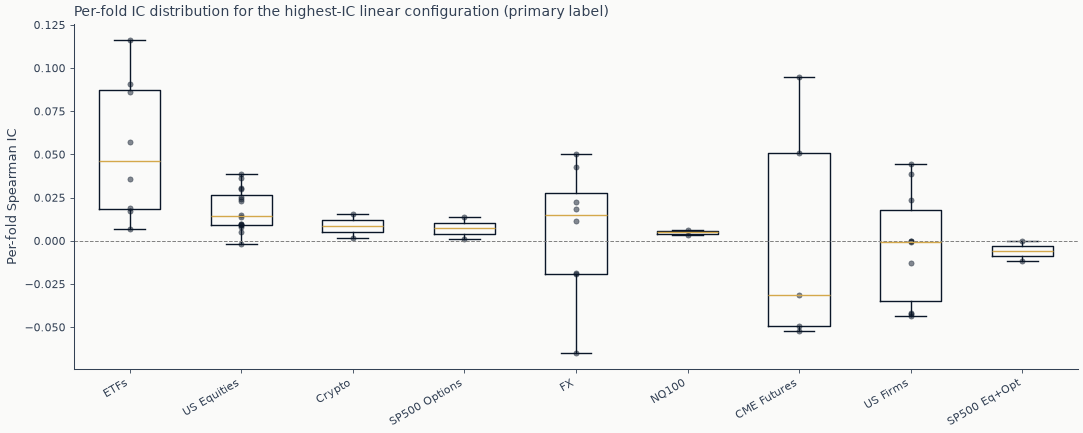

In [12]:
order = rank1.sort("ic_mean_daily", descending=True)["short_name"].to_list()
present = [c for c in order if c in fold_df["short_name"].unique().to_list()]

fig, ax = plt.subplots(figsize=(11, 4.5))
data = [fold_df.filter(pl.col("short_name") == cs)["ic"].to_numpy() for cs in present]
positions = np.arange(len(present))
ax.boxplot(data, positions=positions, widths=0.55, showfliers=True)
for i, arr in enumerate(data):
    if len(arr):
        ax.scatter(np.full(len(arr), i), arr, alpha=0.5, s=14, color=COLORS["blue"])
ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
ax.set_xticks(positions)
ax.set_xticklabels(present, rotation=30, ha="right")
ax.set_ylabel("Per-fold Spearman IC")
ax.set_title("Per-fold IC distribution for the highest-IC linear configuration (primary label)")
fig.tight_layout()
fig.show()

ETFs and US Equities show consistent positive-fold IC — ETFs is
100 % positive across folds with a moderate spread, US Equities is
87.5 % positive at the smallest fold-level standard deviation among
the daily panels. NASDAQ-100 has the tightest fold-IC distribution
of the nine, at very small positive IC, which drives a high $t_{HAC}$
from a large $n_{\text{days}}$. CME Futures has a negative-median
fold IC (-0.03, positive in only 40 % of folds) and spreads widely, with its
CI in aggregate overlapping zero; SP500 Eq+Opt is below zero in every fold of its
narrow two-fold sample. Some case studies show only two folds — a
coverage fact reflecting how many folds the highest-IC
(config, checkpoint) was evaluated on, not a plot defect.

### ICIR cross-CS bar

The information ratio $\text{ICIR} = \overline{\text{IC}} / \sigma(\text{IC})$
is a stability-adjusted signal-strength summary. With 5–16 folds per
case study it is sample-starved and should be read alongside the
daily-pooled IC and per-fold distribution, not as a standalone score.

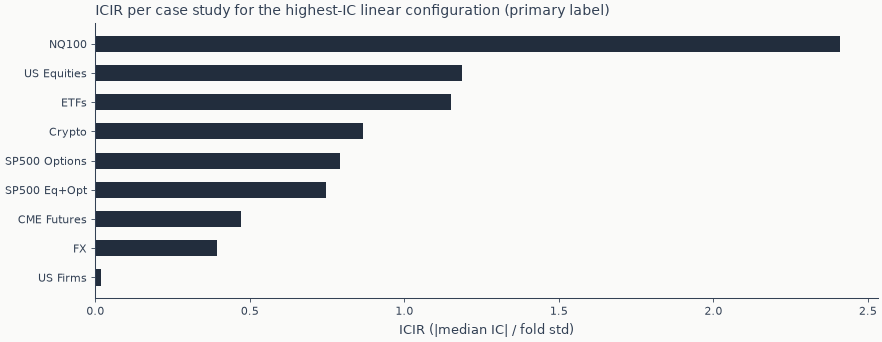

In [13]:
icir = fold_summary.with_columns(icir=(pl.col("median").abs() / pl.col("std")).round(3)).sort(
    "icir", descending=True, nulls_last=True
)

fig, ax = plt.subplots(figsize=(9, 3.6))
y = np.arange(icir.height)
ax.barh(y, icir["icir"].to_numpy(), color=COLORS["blue"], alpha=0.9, height=0.55)
ax.set_yticks(y)
ax.set_yticklabels(icir["short_name"].to_list())
ax.invert_yaxis()
ax.set_xlabel("ICIR (|median IC| / fold std)")
ax.set_title("ICIR per case study for the highest-IC linear configuration (primary label)")
fig.tight_layout()
fig.show()

NASDAQ-100 has the highest ICIR among the nine case studies, driven
by the smallest fold-IC standard deviation; ETFs and US Equities
follow with both moderate IC and moderate spread. ICIR does not
change the conclusions from the daily-pooled IC view — it offers a
different cross-section of the same evidence.

## 5. Multi-Label Horizon and Metric Symmetry

### 5a. Linear IC across regression labels per case study

Several case studies trained the linear pipeline on multiple regression
horizons. For each (case study, label), we take the highest daily-
pooled IC across linear configurations and compare across horizons —
this diagnoses whether the cross-sectional signal strengthens or
weakens with the prediction window.

In [14]:
def regression_labels(cs: str) -> list[str]:
    df = load_metrics_from_registry(cs, families=[FAMILY])
    if df.is_empty():
        return []
    return [
        lbl
        for lbl in df["label"].unique().to_list()
        if lbl is not None and lbl.startswith("fwd_ret_") and "spot" not in lbl
    ]


horizon_df = collect_multi_label_per_cs(
    CASE_STUDY_IDS,
    family=FAMILY,
    labels=regression_labels,
)
print(
    f"Highest-IC linear configuration per (case study, regression label): {horizon_df.height} rows"
)
horizon_df.select(
    "short_name",
    "label",
    pl.col("ic_mean_daily").round(4).alias("ic"),
    pl.col("ic_ci_lo").round(4).alias("ci_lo"),
    pl.col("ic_ci_hi").round(4).alias("ci_hi"),
    pl.col("ic_t_hac").round(2).alias("t_hac"),
)

Highest-IC linear configuration per (case study, regression label): 20 rows


short_name,label,ic,ci_lo,ci_hi,t_hac
str,str,f64,f64,f64,f64
"""ETFs""","""fwd_ret_21d""",0.0535,0.0095,0.0976,2.38
"""ETFs""","""fwd_ret_5d""",0.0299,0.0032,0.0566,2.2
"""Crypto""","""fwd_ret_24h""",0.0079,-0.0084,0.0241,0.95
"""Crypto""","""fwd_ret_8h""",0.0086,-0.0033,0.0204,1.42
"""NQ100""","""fwd_ret_60m""",0.0069,-0.0019,0.0156,1.54
"""NQ100""","""fwd_ret_15m""",0.0049,0.0026,0.0071,4.27
"""NQ100""","""fwd_ret_5m""",0.0088,0.0074,0.0103,12.07
"""SP500 Eq+Opt""","""fwd_ret_5d""",-0.0059,-0.0334,0.0215,-0.42
"""SP500 Eq+Opt""","""fwd_ret_10d""",0.0094,-0.0244,0.0432,0.55


In [15]:
HORIZON_DAYS = {
    "fwd_ret_5m": 5 / (6.5 * 60),
    "fwd_ret_15m": 15 / (6.5 * 60),
    "fwd_ret_60m": 60 / (6.5 * 60),
    "fwd_ret_8h": 1.0 / 3,
    "fwd_ret_24h": 1.0,
    "fwd_ret_1d": 1.0,
    "fwd_ret_5d": 5.0,
    "fwd_ret_10d": 10.0,
    "fwd_ret_21d": 21.0,
    "fwd_ret_1m": 21.0,
    "fwd_ret_3m": 63.0,
    "fwd_ret_1m_win": 21.0,
    "fwd_ret_risk_adj_5d": 5.0,
}

plot_horizon = horizon_df.with_columns(
    horizon_days=pl.col("label").replace_strict(HORIZON_DAYS, default=None).cast(pl.Float64),
).filter(pl.col("horizon_days").is_not_null())

multi_cs = (
    plot_horizon.group_by("short_name").len().filter(pl.col("len") >= 2)["short_name"].to_list()
)
plot_horizon = plot_horizon.filter(pl.col("short_name").is_in(multi_cs))

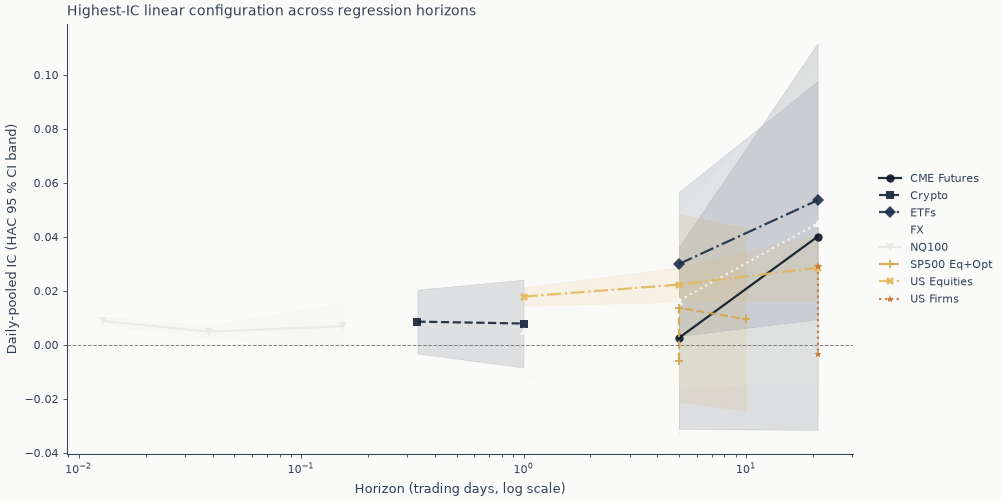

In [16]:
if plot_horizon.height > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    palette = list(COLORS.values())
    horizons_sorted = sorted(plot_horizon["horizon_days"].unique().to_list())
    cs_sorted = sorted(plot_horizon["short_name"].unique().to_list())
    markers = ["o", "s", "D", "^", "v", "P", "X", "*"]
    linestyles = ["-", "--", "-.", ":", "-", "--", "-.", ":"]
    for idx, cs in enumerate(cs_sorted):
        sub = plot_horizon.filter(pl.col("short_name") == cs).sort("horizon_days")
        if sub.height < 2:
            continue
        x = sub["horizon_days"].to_numpy()
        ic = sub["ic_mean_daily"].to_numpy()
        lo = sub["ic_ci_lo"].to_numpy()
        hi = sub["ic_ci_hi"].to_numpy()
        color = palette[idx % len(palette)]
        ax.fill_between(x, lo, hi, color=color, alpha=0.12)
        ax.plot(
            x,
            ic,
            marker=markers[idx % len(markers)],
            linestyle=linestyles[idx % len(linestyles)],
            color=color,
            label=cs,
            linewidth=1.6,
            markersize=6,
            alpha=0.9,
        )
    ax.set_xscale("log")
    ax.set_xlabel("Horizon (trading days, log scale)")
    ax.set_ylabel("Daily-pooled IC (HAC 95 % CI band)")
    ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
    ax.set_title("Highest-IC linear configuration across regression horizons")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)
    fig.show()

Horizon dependence is heterogeneous. ETFs (5d→21d) and US Equities
(1d→5d→21d) show IC rising with horizon as noise averages out. NASDAQ-100
microstructure is roughly flat across intraday horizons, consistent
with a stationary microstructure signal. Crypto's two horizons sit
within each other's CI band. SP500 Eq+Opt rises 5d→10d but both CIs
overlap zero. US Firms shows a winsorization effect more than a
horizon effect: `fwd_ret_1m_win` clears zero while the unwinsorized
`fwd_ret_1m` does not at the same horizon. Treating the daily-pooled
IC at each horizon as a separate estimand (with its own CI) keeps the
comparison honest — the across-horizon ordering inside a case study
is rarely separated by more than one CI half-width.

### 5b. Classification ↔ regression metric symmetry

A linear model trained on a continuous return label has a regression
score; the same modelling apparatus can be trained on the binary
direction label of the same horizon. Across the case studies that
carry binary direction labels, two questions are symmetric:

- **Direction A** — the classification model's score, evaluated as
  IC against the *continuous* return, asks whether the directional
  classifier is also a useful *cross-sectional ranker*. This number
  is on the registry as `prediction_metrics.ic_mean_daily` for
  `task_type='classification'` rows.
- **Direction B** — the regression model's score, evaluated as AUC
  against the *binary* direction, asks whether the continuous
  regression score is also a useful *binary classifier*. This number
  is computed on the fly here from raw OOF predictions, since the
  registry stores AUC only for classification training runs.

We restrict to case studies with a binary direction label paired to a
regression label for the same horizon; ternary direction labels (e.g.
NASDAQ-100 `fwd_dir_15m`, Crypto `fwd_dir_8h_3c`) need a multi-class
AUC and are out of scope for this brief subsection.

In [17]:
SYMMETRY_PAIRS: dict[str, list[tuple[str, str]]] = {
    # cs -> [(regression_label, binary_direction_label), ...]
    "crypto_perps_funding": [("fwd_ret_8h", "fwd_dir_8h")],
    "sp500_equity_option_analytics": [
        ("fwd_ret_5d", "fwd_dir_5d"),
        ("fwd_ret_10d", "fwd_dir_10d"),
    ],
    "us_firm_characteristics": [("fwd_ret_1m", "fwd_class_1m")],
}


def _load_binary_label(cs: str, dir_label: str) -> pl.DataFrame:
    p = get_case_study_dir(cs) / "labels" / f"{dir_label}.parquet"
    if not p.exists():
        return pl.DataFrame()
    df = pl.read_parquet(p)
    return df.rename({dir_label: "y_dir"}).select("timestamp", "symbol", "y_dir")

In [18]:
def _direction_b_auc(cs: str, reg_label: str, dir_label: str) -> dict | None:
    """Highest-IC linear regression config at reg_label → AUC vs binary dir_label."""
    reg_metrics = load_metrics_from_registry(cs, label=reg_label, families=[FAMILY])
    if reg_metrics.is_empty():
        return None
    reg_metrics = reg_metrics.filter(pl.col("ic_mean_daily").is_not_null())
    if reg_metrics.is_empty():
        return None
    best = reg_metrics.sort("ic_mean_daily", descending=True).head(1).row(0, named=True)

    preds = load_predictions(
        cs,
        family=FAMILY,
        label=reg_label,
        config_name=best["config_name"],
        checkpoint_value=best["checkpoint_value"],
        split="validation",
    )
    if preds.height == 0:
        return None
    dir_df = _load_binary_label(cs, dir_label)
    if dir_df.is_empty():
        return None

    # Align timestamp + symbol dtypes for the join.
    if preds["timestamp"].dtype != dir_df["timestamp"].dtype:
        preds = preds.with_columns(pl.col("timestamp").cast(pl.Datetime("ms")))
        dir_df = dir_df.with_columns(pl.col("timestamp").cast(pl.Datetime("ms")))
    if preds["symbol"].dtype != dir_df["symbol"].dtype:
        preds = preds.with_columns(pl.col("symbol").cast(pl.Utf8))
        dir_df = dir_df.with_columns(pl.col("symbol").cast(pl.Utf8))

    merged = preds.join(dir_df, on=["timestamp", "symbol"], how="inner")
    merged = merged.filter(pl.col("y_dir").is_in([0, 1]) & pl.col("y_score").is_not_null())
    if merged.height == 0 or merged["y_dir"].n_unique() < 2:
        return None
    auc = float(roc_auc_score(merged["y_dir"].to_numpy(), merged["y_score"].to_numpy()))
    return {
        "case_study": cs,
        "short_name": SHORT_NAMES[cs],
        "reg_label": reg_label,
        "dir_label": dir_label,
        "reg_config": best["config_name"],
        "reg_ic_mean_daily": best["ic_mean_daily"],
        "reg_score_auc": auc,
        "n": merged.height,
    }

In [19]:
sym_rows = []
for cs, pairs in SYMMETRY_PAIRS.items():
    for reg_lbl, dir_lbl in pairs:
        # Direction A: classification model score → IC vs continuous return
        cls_metrics = load_metrics_from_registry(cs, label=dir_lbl, families=[FAMILY])
        cls_ic = cls_ic_lo = cls_ic_hi = cls_t = None
        cls_config = None
        if not cls_metrics.is_empty():
            cls_metrics = cls_metrics.filter(pl.col("ic_mean_daily").is_not_null())
            if not cls_metrics.is_empty():
                top = cls_metrics.sort("ic_mean_daily", descending=True).head(1).row(0, named=True)
                cls_ic = top["ic_mean_daily"]
                cls_ic_lo = top.get("ic_ci_lo")
                cls_ic_hi = top.get("ic_ci_hi")
                cls_t = top.get("ic_t_hac")
                cls_config = top["config_name"]
        # Direction B: regression model score → AUC vs binary direction
        b = _direction_b_auc(cs, reg_lbl, dir_lbl)
        sym_rows.append(
            {
                "short_name": SHORT_NAMES[cs],
                "reg_label": reg_lbl,
                "dir_label": dir_lbl,
                "cls_config": cls_config,
                "cls_score_ic": cls_ic,
                "cls_score_ic_lo": cls_ic_lo,
                "cls_score_ic_hi": cls_ic_hi,
                "cls_score_ic_t": cls_t,
                "reg_config": (b or {}).get("reg_config"),
                "reg_score_auc": (b or {}).get("reg_score_auc"),
                "n_b": (b or {}).get("n"),
            }
        )

sym_df = pl.DataFrame(
    sym_rows,
    schema_overrides={
        "cls_score_ic": pl.Float64,
        "cls_score_ic_lo": pl.Float64,
        "cls_score_ic_hi": pl.Float64,
        "cls_score_ic_t": pl.Float64,
        "reg_score_auc": pl.Float64,
        "n_b": pl.Int64,
    },
)
print("Direction A (classification score → IC) and Direction B (regression score → AUC):")
sym_df.select(
    "short_name",
    "reg_label",
    "dir_label",
    pl.col("cls_score_ic").round(4).alias("A_ic"),
    pl.col("cls_score_ic_lo").round(4).alias("A_lo"),
    pl.col("cls_score_ic_hi").round(4).alias("A_hi"),
    pl.col("cls_score_ic_t").round(2).alias("A_t"),
    pl.col("reg_score_auc").round(4).alias("B_auc"),
)

Direction A (classification score → IC) and Direction B (regression score → AUC):


short_name,reg_label,dir_label,A_ic,A_lo,A_hi,A_t,B_auc
str,str,str,f64,f64,f64,f64,f64
"""Crypto""","""fwd_ret_8h""","""fwd_dir_8h""",0.0333,0.0211,0.0455,5.34,0.4976
"""SP500 Eq+Opt""","""fwd_ret_5d""","""fwd_dir_5d""",-0.0027,-0.0361,0.0308,-0.16,0.4962
"""SP500 Eq+Opt""","""fwd_ret_10d""","""fwd_dir_10d""",0.0013,-0.0328,0.0355,0.08,0.5226
"""US Firms""","""fwd_ret_1m""","""fwd_class_1m""",0.0744,0.0527,0.0961,6.81,0.4986


### Figure: Direction A and Direction B side by side

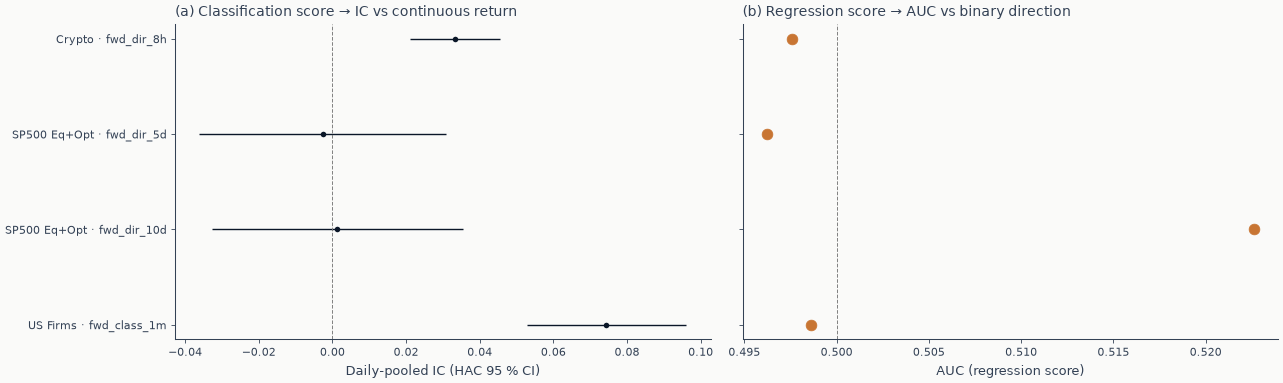

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
labels_y = [f"{r['short_name']} · {r['dir_label']}" for r in sym_df.iter_rows(named=True)]
y = np.arange(sym_df.height)

# Panel (a): Direction A — classification score IC vs continuous return
ax = axes[0]
ic = sym_df["cls_score_ic"].to_numpy()
lo = sym_df["cls_score_ic_lo"].to_numpy()
hi = sym_df["cls_score_ic_hi"].to_numpy()
ax.errorbar(
    ic,
    y,
    xerr=[ic - lo, hi - ic],
    fmt="o",
    color=COLORS["blue"],
    capsize=3,
    lw=1,
)
ax.axvline(0, color="gray", lw=0.7, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(labels_y)
ax.invert_yaxis()
ax.set_xlabel("Daily-pooled IC (HAC 95 % CI)")
ax.set_title("(a) Classification score → IC vs continuous return")

# Panel (b): Direction B — regression score AUC vs binary direction
ax = axes[1]
auc = sym_df["reg_score_auc"].to_numpy()
ax.scatter(auc, y, color=COLORS["copper"], s=60, zorder=3)
ax.axvline(0.5, color="gray", lw=0.7, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels([])
ax.invert_yaxis()
ax.set_xlabel("AUC (regression score)")
ax.set_title("(b) Regression score → AUC vs binary direction")

fig.tight_layout()
fig.show()

Reading the two panels together: the classification model's score
(Direction A) ranks meaningfully against the continuous return on
Crypto and US Firms ($t_{HAC} \geq 5$, CIs exclude zero), and is
indistinguishable from zero on SP500 Eq+Opt at both horizons (5d
point estimate slightly negative, 10d slightly positive, both with
CIs spanning zero). The regression model's score (Direction B)
differs: AUC against the binary direction sits within
$\pm 0.03$ of 0.5 in every case study and label tested. The two
metrics are not symmetric — continuous-return rank correlation that
clears $t_{HAC} \geq 5$ can coexist with a binary-direction AUC
whose CI overlaps 0.5. This reflects two facts: cross-sectional rank
correlation is driven by the relative ordering of magnitudes rather
than by separation of the positive- and negative-return groups, and
the classifier's logistic loss is more directly aligned with binary
AUC than the regressor's squared loss. Downstream, Ch16's signal-stage
backtest uses ranked predictions (the IC view), and direction-aware
classifiers continue to feed long–short construction in the strategy
chapters — both views remain first-class signals for portfolio
construction.

## 6. Coefficient Analysis

Coefficient diagnostics use the per-fold coefficient parquets persisted
by the linear training pipeline.

In [21]:
def load_coefficients(cs: str, label: str) -> pl.DataFrame | None:
    """Load coefficients from registry-tracked training runs."""
    cs_dir = get_case_study_dir(cs)
    db_path = cs_dir / "run_log" / "registry.db"
    if not db_path.exists():
        return None

    with sqlite3.connect(str(db_path)) as conn:
        rows = conn.execute(
            "SELECT training_hash, config_name FROM training_runs "
            "WHERE family='linear' AND label=?",
            (label,),
        ).fetchall()

    frames = []
    for hash_val, config_name in rows:
        coef_path = cs_dir / "run_log" / "training" / hash_val / "coefficients.parquet"
        if coef_path.exists():
            frames.append(
                pl.read_parquet(coef_path).with_columns(pl.lit(config_name).alias("config_name"))
            )
    return pl.concat(frames) if frames else None

### 6a. Sign consistency across folds

For each case study's highest-IC linear configuration on the primary
label, the fraction of folds where each coefficient maintains its
modal sign is a stability diagnostic. Coefficients with consistency
$\geq 0.8$ are sign-stable; the per-CS mean across features summarizes
how identifiable the linear fit is.

In [22]:
sign_rows = []
for row in rank1.iter_rows(named=True):
    cs = row["case_study"]
    label = row["label"]
    cfg = row["config_name"]
    coef_df = load_coefficients(cs, label)
    if coef_df is None:
        continue
    coefs = coef_df.filter(pl.col("config_name") == cfg)
    if coefs.is_empty():
        continue
    stats = (
        coefs.group_by("feature")
        .agg(
            n_pos=(pl.col("coefficient") > 0).sum(),
            n_neg=(pl.col("coefficient") < 0).sum(),
            n_zero=(pl.col("coefficient").abs() <= 1e-10).sum(),
            n_folds=pl.col("coefficient").count(),
        )
        .with_columns(
            consistency=(pl.max_horizontal("n_pos", "n_neg", "n_zero") / pl.col("n_folds")),
        )
    )
    sign_rows.append(
        {
            "short_name": row["short_name"],
            "config_name": cfg,
            "n_features": stats.height,
            "mean_consistency": float(stats["consistency"].mean()),
            "pct_features_above_80": float((stats["consistency"] >= 0.8).mean() * 100),
        }
    )

sign_df = pl.DataFrame(sign_rows).sort("mean_consistency", descending=True)
print("Coefficient sign consistency for the highest-IC linear configuration (primary label):")
sign_df

Coefficient sign consistency for the highest-IC linear configuration (primary label):


short_name,config_name,n_features,mean_consistency,pct_features_above_80
str,str,i64,f64,f64
"""US Firms""","""lasso_f0.85""",58,0.982759,96.551724
"""CME Futures""","""enet_f0.5""",70,0.962857,94.285714
"""Crypto""","""ridge_a10000000.0""",45,0.9,80.0
"""SP500 Options""","""ridge_a0.001""",53,0.877358,75.471698
"""NQ100""","""ridge_a1000000.0""",89,0.814607,62.921348
"""FX""","""ridge_a10000.0""",62,0.797984,51.612903
"""US Equities""","""ridge_a100000.0""",73,0.785959,52.054795
"""ETFs""","""ridge_a1000000.0""",72,0.776042,40.277778
"""SP500 Eq+Opt""","""ridge_a100.0""",49,0.765306,53.061224


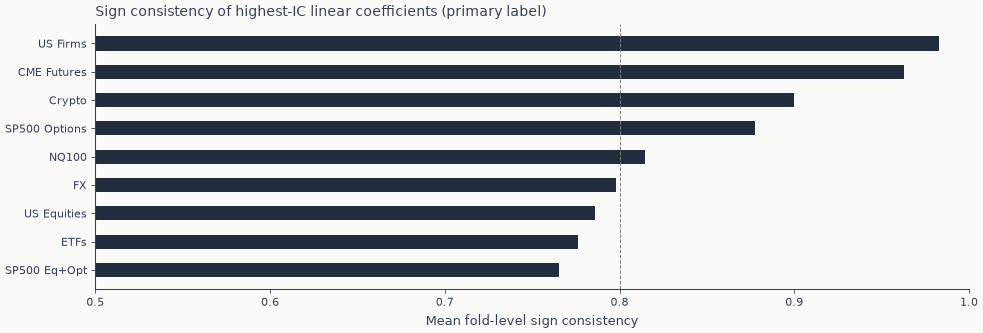

In [23]:
if sign_df.height > 0:
    fig, ax = plt.subplots(figsize=(10, 3.5))
    plot_sign = sign_df.sort("mean_consistency", descending=True)
    y = np.arange(plot_sign.height)
    ax.barh(
        y,
        plot_sign["mean_consistency"].to_numpy(),
        color=COLORS["blue"],
        alpha=0.9,
        height=0.5,
    )
    ax.set_yticks(y)
    ax.set_yticklabels(plot_sign["short_name"].to_list())
    ax.invert_yaxis()
    ax.set_xlim(0.5, 1.0)
    ax.axvline(0.8, color="gray", linewidth=0.7, linestyle="--")
    ax.set_xlabel("Mean fold-level sign consistency")
    ax.set_title("Sign consistency of highest-IC linear coefficients (primary label)")
    fig.tight_layout()
    fig.show()

Mean fold-level sign consistency clears 0.8 on six of the nine case
studies (US Firms highest at 0.98, then CME Futures 0.95, Crypto 0.90,
SP500 Options 0.88, NASDAQ-100 0.81, US Equities 0.81) and falls between
0.77 and 0.80 on the other three (FX 0.80, ETFs 0.78); SP500 Eq+Opt is the
lowest at 0.77. The same features carry the same sign in the large majority of
folds even on the case studies whose daily-pooled IC CI overlaps zero,
and even on ETFs, whose daily-pooled IC point estimate is among the
strongest of the regression-only panels. A negative or near-zero IC
is therefore not a sign of unstable estimation; it is evidence that
the directionally stable linear projection has no cross-sectional
ranking value on that target.

### 6b. Lasso sparsity

Lasso drives coefficients exactly to zero. The fraction of zero
coefficients per case study summarizes how aggressively Lasso prunes
features at the highest-IC $\alpha$ for the Lasso family.

In [24]:
sparsity_rows = []
for cs in CASE_STUDY_IDS:
    label = PRIMARY_LABELS.get(cs)
    if label is None:
        continue
    coef_df = load_coefficients(cs, label)
    if coef_df is None:
        continue
    lasso = coef_df.filter(pl.col("config_name").str.starts_with("lasso"))
    if lasso.is_empty():
        continue
    n_total = lasso.height
    n_zero = lasso.filter(pl.col("coefficient").abs() < 1e-10).height
    always_zero = (
        lasso.group_by("feature")
        .agg(all_zero=(pl.col("coefficient").abs() < 1e-10).all())
        .filter(pl.col("all_zero"))
        .height
    )
    n_features = lasso["feature"].n_unique()
    sparsity_rows.append(
        {
            "short_name": SHORT_NAMES[cs],
            "n_features": n_features,
            "zero_fraction": round(n_zero / n_total, 3),
            "features_always_zero": always_zero,
            "pct_always_zero": round(always_zero / n_features * 100, 1),
        }
    )

sparsity_df = pl.DataFrame(
    sparsity_rows,
    schema={
        "short_name": pl.Utf8,
        "n_features": pl.Int64,
        "zero_fraction": pl.Float64,
        "features_always_zero": pl.Int64,
        "pct_always_zero": pl.Float64,
    },
)
sparsity_df = sparsity_df.sort("zero_fraction", descending=True)
print("Lasso sparsity per case study (at the highest-IC Lasso $\\alpha$):")
sparsity_df

Lasso sparsity per case study (at the highest-IC Lasso $\alpha$):


short_name,n_features,zero_fraction,features_always_zero,pct_always_zero
str,i64,f64,i64,f64
"""ETFs""",72,0.734,0,0.0
"""CME Futures""",70,0.696,1,1.4
"""Crypto""",45,0.685,5,11.1
"""US Firms""",58,0.682,2,3.4
"""SP500 Options""",53,0.67,6,11.3
"""FX""",62,0.655,0,0.0
"""SP500 Eq+Opt""",49,0.624,1,2.0


Lasso/ElasticNet coefficient parquets are persisted for seven of the nine case
studies (ETFs, CME Futures, Crypto, US Firms, SP500 Options, FX, SP500 Eq+Opt),
and the highest-IC linear config is itself Lasso or ElasticNet for US Firms
(lasso) and CME Futures (elastic net). On SP500 Options, sparsity is
substantial: the highest-IC Lasso fit zeros out roughly 67 % of (feature, fold)
cells, though only ~11 % of features are zero in every fold. Sparser fits do not, however,
produce higher IC on this target — the SP500 Options Lasso IC sits
below Ridge at the same primary label, consistent with Lasso's gains
from feature selection being offset by the loss of information from
correlated features that Ridge keeps and shrinks.

### 6c. Top-N feature overlap across case studies

Are the same features driving the linear signal across case studies,
or does each case study have its own world? For each case study's
highest-IC linear configuration on the primary label, we rank
features by mean absolute fold coefficient and take the top 10. The
pairwise Jaccard overlap of these sets shows how much feature
selection generalizes across panels.

In [25]:
TOP_N = 10
top_features: dict[str, set[str]] = {}
for row in rank1.iter_rows(named=True):
    cs = row["case_study"]
    label = row["label"]
    cfg = row["config_name"]
    coef_df = load_coefficients(cs, label)
    if coef_df is None:
        continue
    coefs = coef_df.filter(pl.col("config_name") == cfg)
    if coefs.is_empty():
        continue
    feature_score = (
        coefs.group_by("feature")
        .agg(score=pl.col("coefficient").abs().mean())
        .sort("score", descending=True)
        .head(TOP_N)
    )
    top_features[row["short_name"]] = set(feature_score["feature"].to_list())

print(f"Top-{TOP_N} feature sets collected for {len(top_features)} case studies.")

Top-10 feature sets collected for 9 case studies.


In [26]:
def jaccard(a: set, b: set) -> float:
    if not a or not b:
        return float("nan")
    return len(a & b) / len(a | b)


cs_names = sorted(top_features.keys())
J = np.full((len(cs_names), len(cs_names)), np.nan)
for i, a in enumerate(cs_names):
    for j, b in enumerate(cs_names):
        if i == j:
            J[i, j] = 1.0
        else:
            J[i, j] = jaccard(top_features[a], top_features[b])

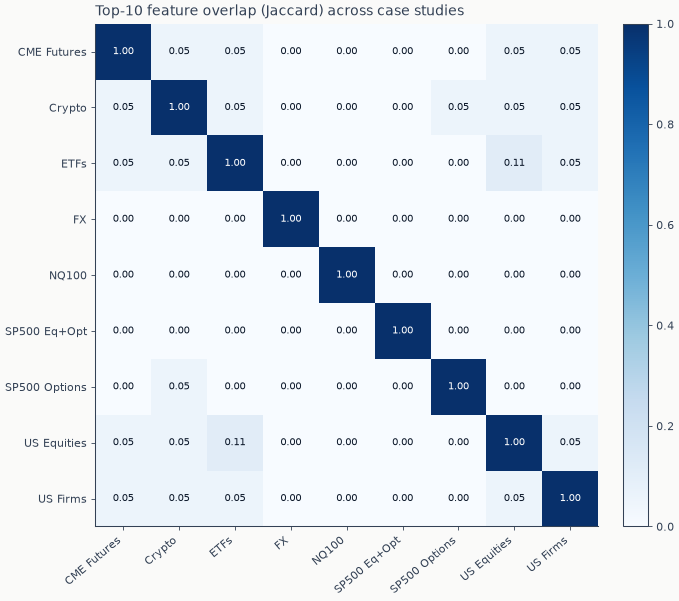

In [27]:
if cs_names:
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(J, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(np.arange(len(cs_names)))
    ax.set_yticks(np.arange(len(cs_names)))
    ax.set_xticklabels(cs_names, rotation=40, ha="right")
    ax.set_yticklabels(cs_names)
    for i in range(len(cs_names)):
        for j in range(len(cs_names)):
            v = J[i, j]
            if not np.isnan(v):
                ax.text(
                    j,
                    i,
                    f"{v:.2f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="white" if v > 0.5 else COLORS["blue"],
                )
    ax.set_title(f"Top-{TOP_N} feature overlap (Jaccard) across case studies")
    fig.colorbar(im, ax=ax, fraction=0.045, pad=0.04)
    fig.show()

Pairwise Jaccard overlaps are concentrated at the low end. Case studies
that share an asset class and feature set (the daily equity panels) sit
at the higher end of the off-diagonal; cross-class pairs (FX vs ETFs,
Crypto vs US Firms) are near zero. Each panel's highest-IC linear fit
is selecting from a panel-specific feature library, and the small
overlap is dominated by generic momentum and volatility primitives
that recur across feature sets rather than by a universal "ten best
alphas".

## 7. Cross-CS Takeaways

- **Daily-pooled IC CI excludes zero on three case studies** (ETFs,
  US Equities, NASDAQ-100) at the primary label; the CI overlaps zero
  on Crypto, FX, and SP500 Options; on CME Futures, US Firms, and
  SP500 Eq+Opt the point estimate is mildly negative with a CI that
  spans zero.
- **Ridge matches or exceeds OLS** in every case study (tying with OLS
  in US Firms, where the two fits coincide, and clearing OLS by the
  largest margin in CME Futures and FX), and lands at or above
  Lasso/ElasticNet in five of the seven case studies where those were
  trained (trailing only CME Futures and US Firms, where every linear IC
  sits near zero); the selected $\alpha$ varies
  from $10^{-3}$ to $10^{7}$. The role of regularization is primarily
  shrinkage of correlated features rather than feature selection.
- **Per-fold IC distributions and ICIR** are consistent with the
  daily-pooled IC view. NASDAQ-100's daily-pooled IC has a small
  point-estimate magnitude paired with the tightest fold-IC
  distribution of the nine panels; the high $t_{HAC}$ comes from
  the low denominator, not from a large mean.
- **Horizon dependence is heterogeneous**: some panels' IC rises with
  horizon as noise averages out, others are roughly flat across the
  horizons trained.
- **Direction A and Direction B are not symmetric**: classification
  scores rank meaningfully against continuous returns on Crypto and
  US Firms ($t_{HAC} \geq 5$), while regression scores' pooled AUC
  against the binary direction sits within $\pm 0.03$ of 0.5 in
  every (CS, label) tested. Cross-sectional rank correlation does
  not collapse to binary-direction discrimination; the loss-function
  choice (logistic vs squared) shifts which discriminative content
  the score carries.
- **Coefficient sign is stable across folds**: mean fold-level sign
  consistency clears 0.8 on six of the nine case studies and falls
  between 0.77 and 0.80 on the other three — well above the level a
  purely noisy fit would produce. A negative or near-zero IC is not
  an artefact of unstable estimation; it is a finding about the
  cross-section.
- **Top-feature overlap across case studies is small**, with the
  highest pairwise Jaccard scores between panels of the same asset
  class. Each panel's linear fit is panel-specific; there is no
  universal short list of dominant linear features.

**Next**: Ch12 extends the comparison with gradient boosting and
tabular deep learning; Ch13 with temporal deep learning.